## Imports iniciais

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
import math as mt

## Abro o arquivo e vejo suas informações

In [2]:
df_games = pd.read_csv('games.csv')
print(df_games.head()) # Exibindo as primeiras 5 linhas do DataFrame
print()
print(df_games.info()) # Exibindo informações sobre o DataFrame, como o número de linhas, colunas e tipos de dados
print()
print(df_games.sample(15)) # Exibindo uma amostra aleatória de 5 linhas do DataFrame

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):


## Limpeza dos dados
- Primeiro coloco todas as colunas em minúsculas
- Depois converto os dados para os tipos necessários
- Verifico os valores ausentes e tomo decisões de como lidar com eles

In [3]:
df_games.columns = [col.lower() for col in df_games.columns]
print(df_games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')


In [4]:
df_games['year_of_release'] = df_games['year_of_release'].astype('Int64') # Convertendo a coluna year_of_release para o tipo inteiro
# Isso foi feito para que possamos realizar operações numéricas de forma mais eficiente.


### Verificando dados ausentes

In [5]:
print(df_games.isna().sum()) # Verificando a quantidade de valores nulos em cada coluna do DataFrame

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64


In [6]:
print(df_games[df_games['name'].isna()]) # Verificando as linhas com valores nulos na coluna 'name'
df_games = df_games.dropna(subset=['name', 'genre']) # Removendo as linhas com valores nulos na coluna 'name' e 'genre'

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN             1993   NaN      1.78      0.53      0.00   
14244  NaN      GEN             1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


Os 2 únicos valores ausentes de 'name' e 'genre' são valores com poucas informações e a exclusão deles não trará diferenças significativas para a análise.
Ambos estão ausentes na mesma linha

In [7]:
df_games['rating'] = df_games['rating'].fillna('Unknown') # Preenchendo os valores nulos na coluna 'rating' com a string 'Unknown'
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce') # Convertendo a coluna 'user_score' para o tipo numérico, substituindo valores não numéricos por NaN

### Motivo dos ausentes
Os valores ausentes em 'name' e 'genre' não possuem informações suficientes e provavelmente não foram preenchidos corretamente.
Os ausentes nas colunas de avaliação ('critic_score', 'user_score' e 'rating') ocorrem porque órgãos de avaliação se consolidaram a partir dos anos 2000, o que explica a maior disponibilidade de notas em jogos mais recentes.

### Decisão com os valores ausentes
- Os 269 registros sem 'year_of_release' ainda possuem informações de vendas; optou-se por mantê-los para não perder volume de dados em análises agregadas por plataforma (mas eles são excluídos quando necessário para análises por ano).
- Em relação à coluna 'rating', preenchemos valores nulos com 'Unknown' para preservar o máximo de dados ao agrupar por classificação.
- A coluna 'user_score' contém valores como 'tbd' (to be determined); a conversão para numérico transforma esses valores em NaN, o que facilita cálculos estatísticos posteriores.
- A coluna 'critic_score' possui nulos; optou-se por não imputar média/mediana para evitar introduzir viés em análises de desempenho.

In [8]:
df_games['total_sales'] = df_games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1) # Somando as vendas de todas as regiões para cada jogo
df_games = df_games[['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales', 'critic_score', 'user_score', 'rating']] # Reorganizando as colunas do DataFrame

## Analisando os dados

In [9]:
count_games_by_year = df_games.groupby('year_of_release').size().reset_index(name='count') # Contando a quantidade de jogos lançados por ano
print(count_games_by_year.sample(15, random_state=42).sort_index()) # Exibindo uma amostra aleatória de 15 linhas do DataFrame count_games_by_year, ordenadas pelo índice

    year_of_release  count
4              1984     14
6              1986     21
8              1988     15
9              1989     17
12             1992     43
13             1993     60
15             1995    219
16             1996    263
17             1997    289
24             2004    762
25             2005    939
26             2006   1006
29             2009   1426
32             2012    653
35             2015    606


Com uma amostra da quantidade de jogos lançados por ano, pode-se confirmar que há uma diferença consideravelmente grande na quantidade lançada do século XX para o XXI

In [10]:
sales_by_platform = df_games.groupby(['platform'])['total_sales'].sum().reset_index(name='total_sales') # Agrupando as vendas totais por plataforma
sales_by_platform_year = df_games.groupby(
    ['platform', 'year_of_release'])['total_sales'].sum().reset_index(name='total_sales') # Agrupando as vendas totais por plataforma e ano de lançamento
print(sales_by_platform.sort_values('total_sales', ascending=False).head(5)) # Exibindo as 5 plataformas com maior quantidade de vendas totais

   platform  total_sales
16      PS2      1255.77
28     X360       971.42
17      PS3       939.65
26      Wii       907.51
4        DS       806.12


As 5 plataformas com mais vendas são PS2, X360, PS3, Wii e DS

In [11]:
top_5_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS'] # Selecionando as 5 plataformas com maior quantidade de vendas totais
top5_sales_platform = df_games[df_games['platform'].isin(top_5_platforms)].groupby(
    ['platform', 'year_of_release'], dropna=False)['total_sales'].sum().reset_index()
# Agrupando as vendas totais por plataforma e ano de lançamento, considerando apenas as 5 plataformas selecionadas

## Criando um grafico de distribuição

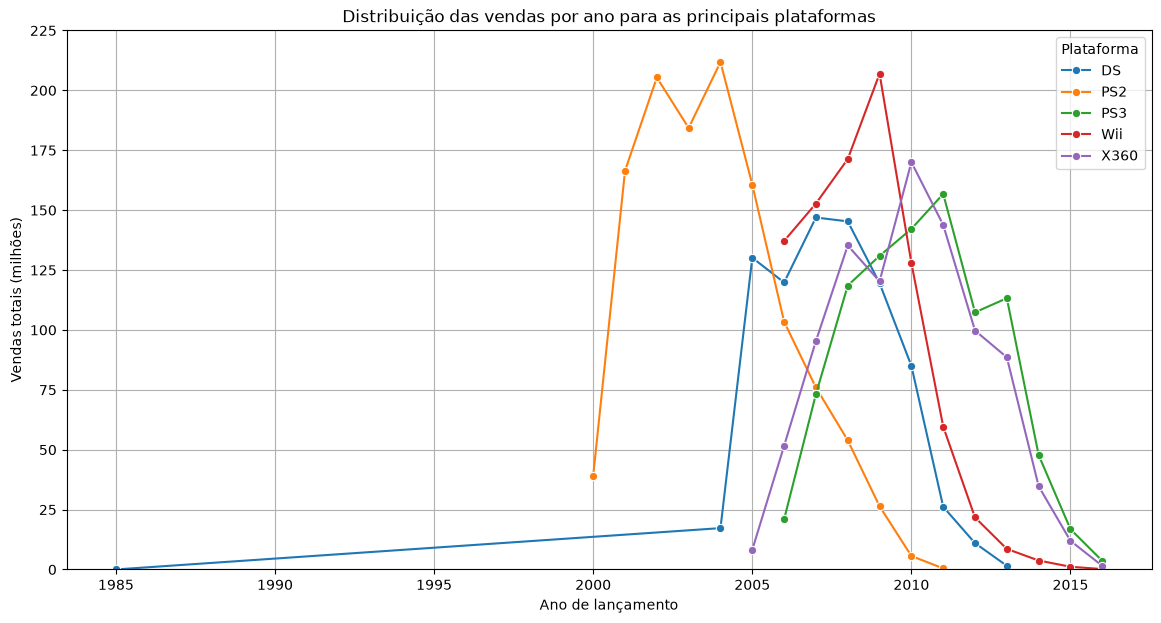

In [12]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=top5_sales_platform,
    x='year_of_release',
    y='total_sales',
    hue='platform',
    marker='o'
) # Criando um gráfico de linha para visualizar a distribuição das vendas por ano para as principais plataformas
plt.title('Distribuição das vendas por ano para as principais plataformas') # Adicionando um título ao gráfico
plt.xlabel('Ano de lançamento') # Adicionando um rótulo ao eixo x
plt.ylabel('Vendas totais (milhões)') # Adicionando um rótulo ao eixo y
plt.grid() # Adicionando uma grade ao gráfico
plt.ylim(0, 225) # Definindo os limites do eixo y
plt.legend(title='Plataforma')
plt.show() # Exibindo o gráfico

Pode-se observar que a Nintendo DS era única com a melhores vendas até meados de 2004, quando em 2000 surgiu o PS2 e logo dominou o mercado. Entre 2000 e 2011, não só o PS2 surgiu, como Xbox 360 (2005), Nintendo Wii (2006) e PS3 (2007) também, e atingiram seu pico de vendas, quando após 2011 todas as 5 plataformas apresentaram declínios nas vendas.

platform
XOne    2013
PS4     2013
WiiU    2012
3DS     2011
PSV     2011
DC      2007
DS      2007
GBA     2007
PS3     2007
PS2     2007
PC      2007
GC      2007
Wii     2007
PSP     2007
X360    2007
XB      2007
Name: year_of_release, dtype: Int64


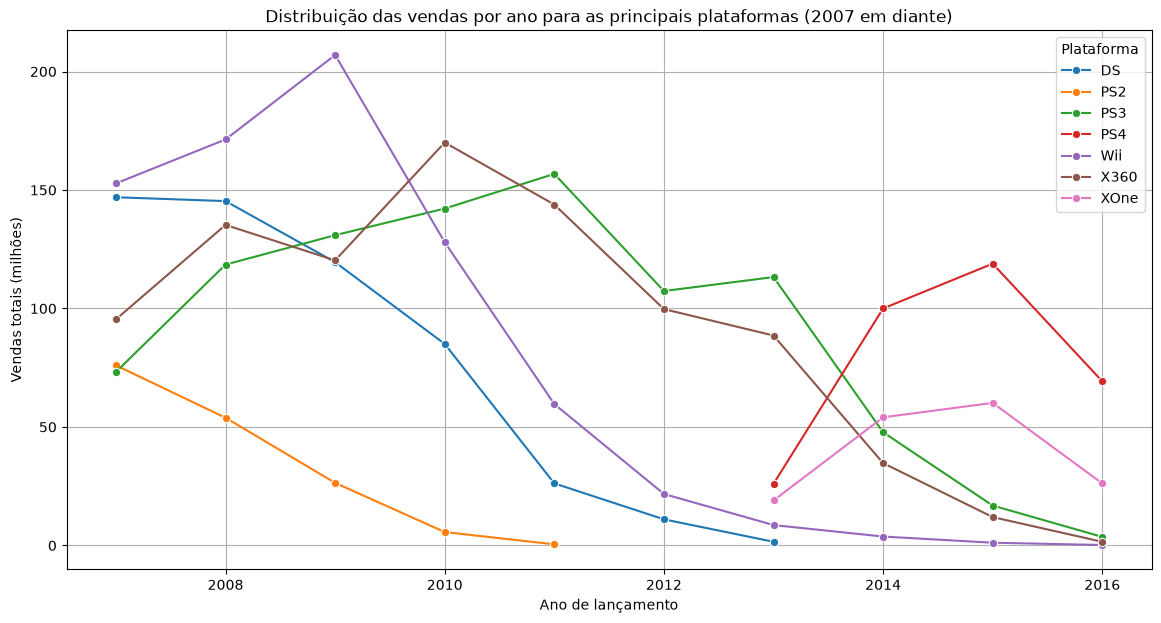

In [13]:
# Analisando o ano inicial de vendas nas principais plataformas, considerando apenas os anos a partir de 2007
print(
    df_games[df_games['year_of_release'] >= 2007]
    .groupby('platform')['year_of_release']
    .min()
    .sort_values(ascending=False)
)
extra_platforms = ['PS4', 'XOne'] # Selecionando as plataformas adicionais para análise
selected_platforms = top_5_platforms + extra_platforms # Combinando as plataformas principais com as adicionais
sales_after_2007 = (
    df_games[(df_games['year_of_release'] >= 2007) & (df_games['platform'].isin(selected_platforms))]
    .groupby(['platform', 'year_of_release'], dropna=False)['total_sales']
    .sum()
    .reset_index()
    .sort_values(['platform', 'year_of_release'])
)
plt.figure(figsize=(14, 7))
sns.lineplot(data=sales_after_2007,
             x='year_of_release',
             y='total_sales',
             hue='platform',
             marker='o') # Criando um gráfico de linha para visualizar a distribuição das vendas por ano para as principais plataformas.
plt.title('Distribuição das vendas por ano para as principais plataformas (2007 em diante)') # Adicionando um título ao gráfico
plt.xlabel('Ano de lançamento') # Adicionando um rótulo ao eixo x
plt.ylabel('Vendas totais (milhões)') # Adicionando um rótulo ao eixo y
plt.legend(title='Plataforma')
plt.grid()
plt.show() # Exibindo o gráfico

### Especificações da tabela

> - O gráfico analisa plataformas com vendas a partir de 2007, incluindo plataformas consolidadas e as plataformas mais recentes.
> - A escolha de apenas 2 plataformas adicionais no gráfico foi para reduzir o ruído e manter a visualização mais clara.


### Ascensão das novas plataformas

No gráfico acima, é possível notar que, a partir de 2007, PS3 e Xbox 360 ainda aparecem com vendas, mas em volumes menores do que nos seus picos anteriores. PS4 e Xbox One surgem mais tarde e mostram um crescimento rápido até cerca de 2015, quando começam a declinar.

Essa análise indica que as plataformas de nova geração tiveram vendas significativas, mas não chegaram a superar de imediato os picos de vendas das plataformas da era anterior, como Wii e PS2. O resultado também reflete um mercado mais fragmentado, em que diferentes gerações de consoles coexistem.

As plataformas mais antigas se mantiveram no topo por 6 anos e após 2010 já demonstraram quedas significativas, após 3 anos ja tivemos a inserção de novas plataformas que logo substiruiram a geração anterior

In [14]:
print(df_games['year_of_release'].value_counts().sort_index().tail(10)) # Analisando a quantidade de jogos lançados nos ultimos 10 anos
sales_by_platform_year_after_2012 = sales_by_platform_year[sales_by_platform_year['year_of_release'] >= 2012].groupby(
    ['year_of_release', 'platform'])['total_sales'].sum().reset_index()
# Filtrando as vendas totais por ano de lançamento a partir de 2012


year_of_release
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: Int64


A partir de 2012, o numero de jogos lançados em relaçao a 2011 é pouco mais da metade. Por esse motivo, foi optado em usar dados de 2012 em diante

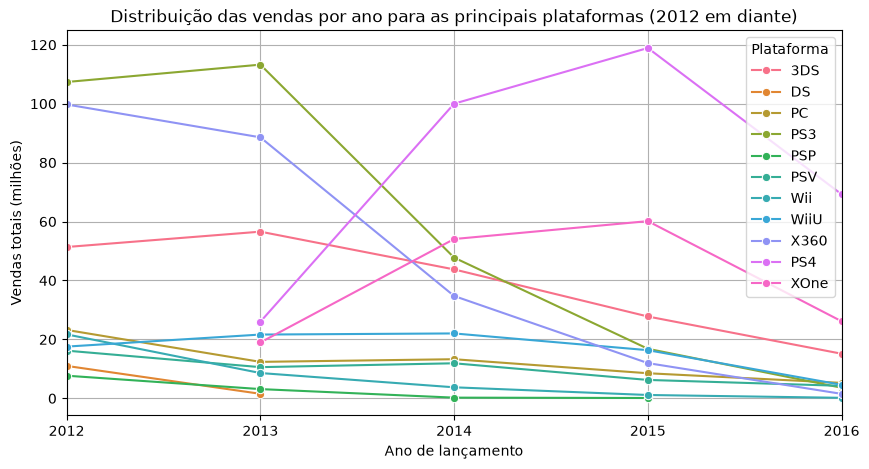

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=sales_by_platform_year_after_2012,
             x='year_of_release',
             y='total_sales',
             hue='platform',
             marker='o') # Criando um gráfico de linha para visualizar a distribuição das vendas por
plt.title('Distribuição das vendas por ano para as principais plataformas (2012 em diante)') # Adicionando um título ao gráfico
plt.xlabel('Ano de lançamento') # Adicionando um rótulo ao eixo x
plt.ylabel('Vendas totais (milhões)') # Adicionando um rótulo ao eixo y
plt.xlim(2012, 2016) # Definindo os limites do eixo x
plt.legend(title='Plataforma')
plt.xticks(sales_by_platform_year_after_2012['year_of_release'].unique())
plt.grid()
plt.show() # Exibindo o gráfico

## Previsão para 2017
O gráfico sugere que PS4 e Xbox One tem maior potencial para 2017, pois exibem vendas mais consistentes após seus lançamentos. PS3 e Xbox 360 apresentam queda, o que indica menor expectativa de desempenho forte no ano seguinte. 3DS ainda mantém um volume relevante, mas já mostra sinais de estabilização.

### Conclui-se que:
- PS4 e Xbox One eram as plataformas com maior chance de continuar vendendo bem em 2017.
- PS3 e Xbox 360 estavam em declínio, com menor probabilidade de crescimento em 2017.
- 3DS ainda era relevante, mas não aparentava estar em crescimento acelerado.
- Outras plataformas como DS, PSP, PSV, já encerraram seu ciclo de vida, ou estão em declínio acentuado, sem expectativa para anos futuros


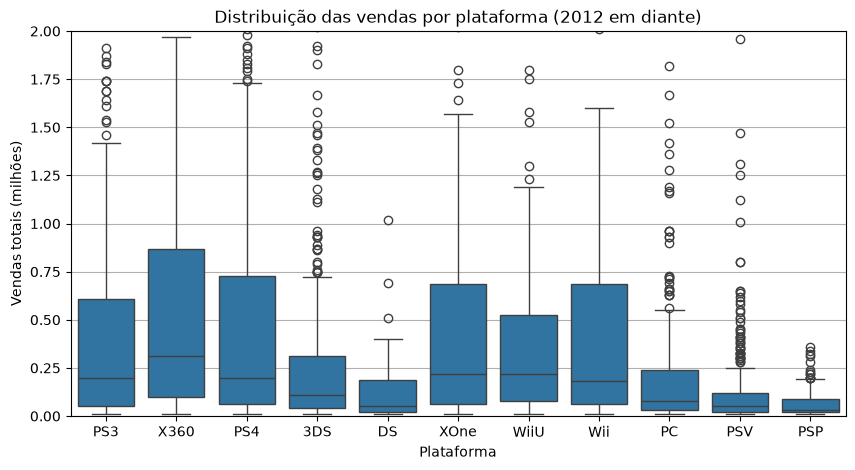

In [16]:
df_recent_games = df_games[df_games['year_of_release'] >= 2012]
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_recent_games,
            x='platform',
            y='total_sales') # Criando um boxplot para visualizar a distribuição das vendas por plataforma a partir de 2012
plt.ylim(0, 2) # Definindo os limites do eixo y
plt.title('Distribuição das vendas por plataforma (2012 em diante)') # Adicionando um título ao gráfico
plt.xlabel('Plataforma') # Adicionando um rótulo ao eixo x
plt.ylabel('Vendas totais (milhões)') # Adicionando um rótulo ao eixo y
plt.grid(axis='y')
plt.show() # Exibindo o gráfico

## Conclusão sobre as vendas globais

Consoles de mesa (PS4, XOne, X360 e PS3) apresentam medianas entre 200 e 300 mil cópias por jogo; PC e plataformas portáteis registram medianas abaixo de 100 mil cópias.

Apesar das medianas moderadas, o faturamento agregado é fortemente influenciado por outliers que alcançam vendas na casa dos milhões de cópias.


## Como as avaliações afetam nas vendas?

Para realizar esse estudo, será usado os dados da plataforma PS4, por ser a mais recente

In [17]:
ps4_data = df_games[(df_games['platform'] == 'PS4') & (df_games['year_of_release'] >= 2012)].reset_index(drop=True)
# Separa um dataframe filtrado com a plataforma PS4 e o ano de lançamendo do console (2012)

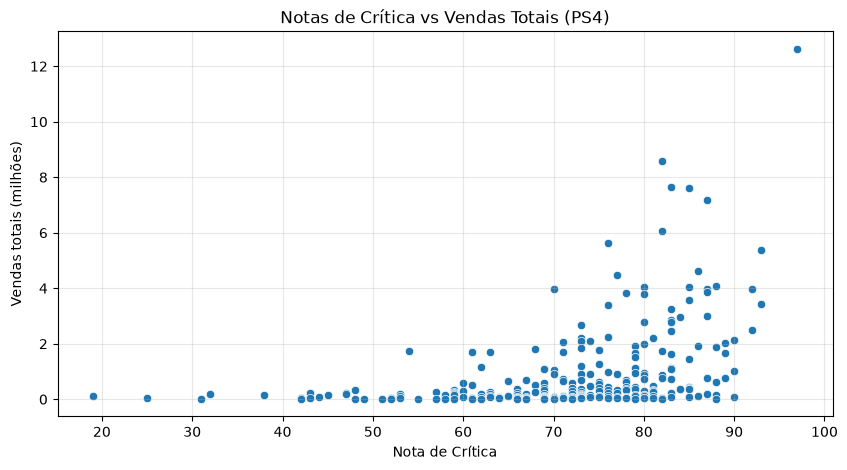

In [18]:
plt.figure(figsize=(10,5)) # Determina o tamanho do grafico
sns.scatterplot(data=ps4_data,
                x='critic_score',
                y='total_sales')
plt.title('Notas de Crítica vs Vendas Totais (PS4)') # Define um titulo
plt.xlabel('Nota de Crítica') # Legenda pro eixo X
plt.ylabel('Vendas totais (milhões)') # Legenda pro eixo Y
plt.grid(alpha=0.3) # Transparencia na grade do fundo para melhor vizualização
plt.show()

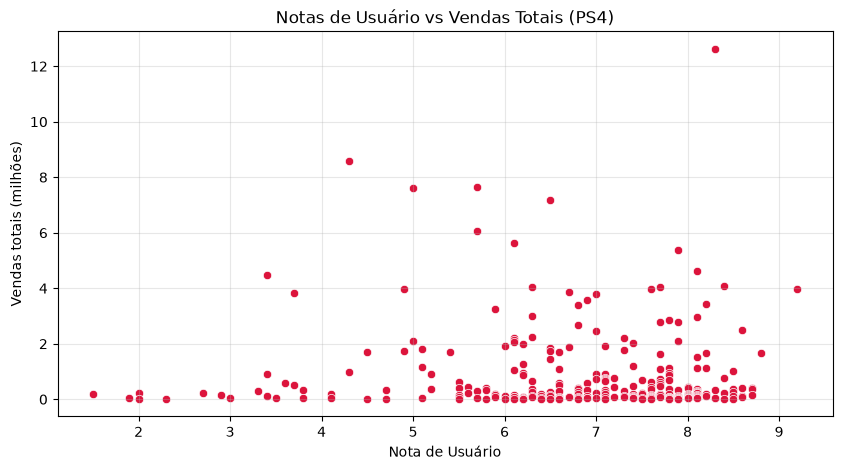

In [19]:
plt.figure(figsize=(10,5)) # Determina o tamanho do grafico
sns.scatterplot(data=ps4_data,
                x='user_score',
                y='total_sales',
                color='crimson')
plt.title('Notas de Usuário vs Vendas Totais (PS4)') # Define um titulo
plt.xlabel('Nota de Usuário') # Legenda pro eixo X
plt.ylabel('Vendas totais (milhões)') # Legenda pro eixo Y
plt.grid(alpha=0.3) # Transparencia na grade do fundo para melhor vizualização
plt.show()

In [20]:
corr_critic = ps4_data['critic_score'].corr(ps4_data['total_sales']).round(2) # Obtem a correlação da nota de crítica
corr_user = ps4_data['user_score'].corr(ps4_data['total_sales']).round(2) # Obtem a correlação da nota de usuario

print(f"Notas da Crítica vs Vendas: {corr_critic}")
print(f"Notas dos Usuários vs Vendas: {corr_user}")

Notas da Crítica vs Vendas: 0.41
Notas dos Usuários vs Vendas: -0.03


## Conclusão sobre Avaliações x Vendas

Observa-se que os jogos com a nota critica possuem uma correlação positiva moderada, indicando que jogos bem avaliados pela imprensa costumam vender mais, em contrapartida, a correlação negativa das notas de usuarios, não demonstra ligação com as vendas\
Pode-se observar nos graficos que apenas um pequeno grupo de jogos possuem um faturamento alto que combina com a nota recebida

## Vendas dos mesmos jogos em diferentes plataformas

In [21]:
top_ps4_games = ps4_data.sort_values(by='total_sales', ascending=False)['name'].head(10) # Obtem os 10 melhores jogos do PS4
multiplatform_games = df_games[(df_games['name'].isin(top_ps4_games) & (df_games['year_of_release'] >= 2012))] # Cria um novo dataframe filtrado
sales_comparison = multiplatform_games.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).fillna(0) # Cria uma tabela dinamica, ligando a plataformas com 10 jogos selecionado
print(sales_comparison) # Exibe a tabela

platform                         3DS    PC    PS3    PS4  PSV   Wii   X360  \
name                                                                         
Call of Duty: Advanced Warfare  0.00  0.41   4.36   7.66  0.0  0.00   4.28   
Call of Duty: Black Ops 3       0.00  0.26   1.69  14.63  0.0  0.00   1.70   
Destiny                         0.00  0.00   1.61   5.64  0.0  0.00   1.92   
FIFA 15                         0.46  0.29   4.28   6.08  0.6  0.56   2.92   
FIFA 16                         0.00  0.20   2.70   8.58  0.0  0.00   1.57   
FIFA 17                         0.00  0.12   0.73   7.60  0.0  0.00   0.38   
Fallout 4                       0.00  1.28   0.00   7.17  0.0  0.00   0.00   
Grand Theft Auto V              0.00  1.17  21.05  12.62  0.0  0.00  16.27   
Star Wars Battlefront (2015)    0.00  0.55   0.00   7.98  0.0  0.00   0.00   
Uncharted 4: A Thief's End      0.00  0.00   0.00   5.39  0.0  0.00   0.00   

platform                        XOne  
name                    

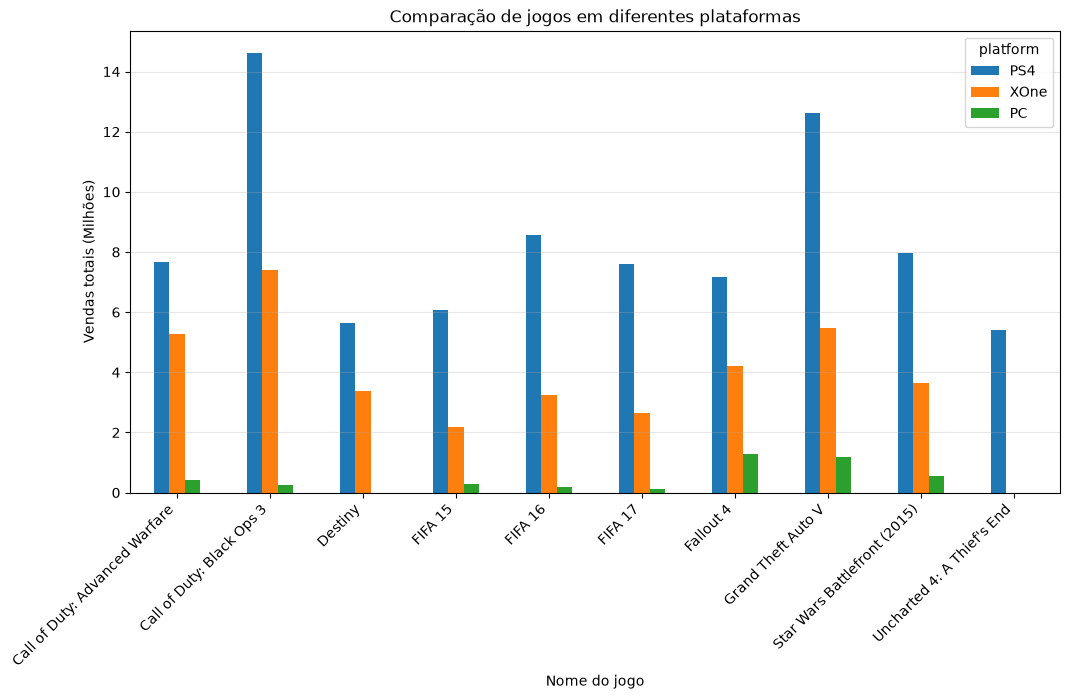

In [22]:
sales_comparison[['PS4', 'XOne', 'PC']].plot(kind='bar',
                                             figsize=(12, 6),
                                             title='Comparação de jogos em diferentes plataformas',
                                             xlabel='Nome do jogo',
                                             ylabel='Vendas totais (Milhões)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

O gráfico mostra claro domínio do PS4, que apresenta praticamente o dobro de vendas em relação ao Xbox One em vários títulos; isso indica uma base de usuários robusta para a Sony.

Uncharted 4, presente apenas em uma plataforma, ainda assim demonstra números de vendas elevados em comparação a outros títulos multiplataforma.

Observa-se vendas relativamente baixas no PC (menos de US$2 milhões por jogo na amostra), possivelmente porque muitas vendas de PC são digitais e não são totalmente refletidas nos dados físicos da base.


In [23]:
genre_analysis = df_recent_games.groupby('genre').agg(
    total_sales=('total_sales', 'sum'),
    game_count=('name', 'count')).sort_values(by='total_sales', ascending=False)
# Realiza um agrupamento, agregando o total de vendas e quantidade de jogos por genero
print(genre_analysis)

              total_sales  game_count
genre                                
Action             441.12        1031
Shooter            304.73         235
Role-Playing       192.80         370
Sports             181.07         268
Misc                85.04         192
Platform            61.00          85
Racing              53.50         115
Fighting            44.49         109
Simulation          35.12          80
Adventure           29.43         302
Strategy            13.34          71
Puzzle               4.89          28


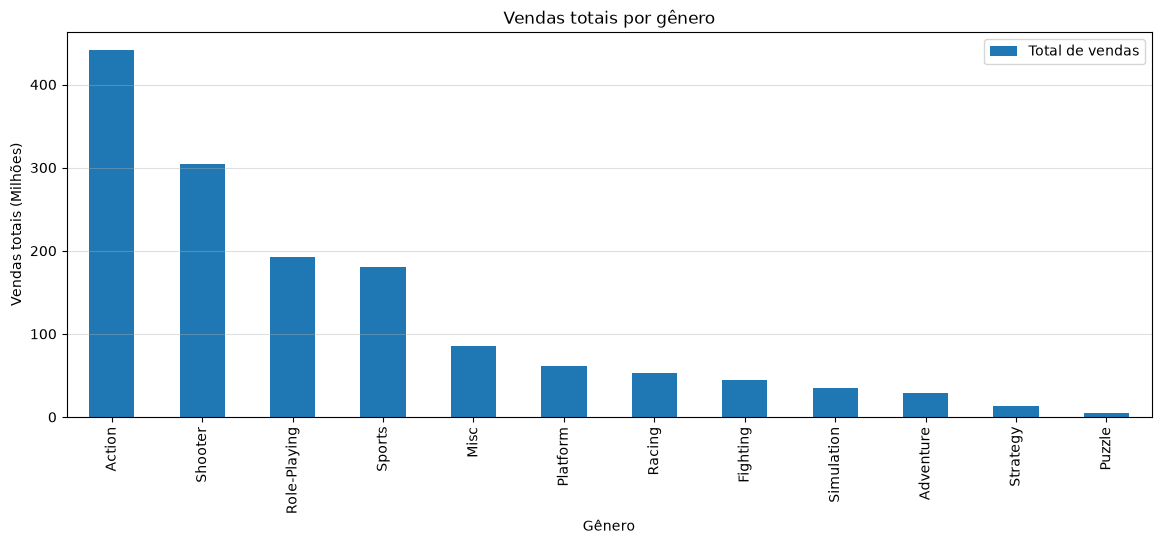

In [24]:
genre_analysis['total_sales'].plot(kind='bar',
                    title='Vendas totais por gênero',
                    xlabel='Gênero',
                    ylabel='Vendas totais (Milhões)',
                    figsize=(14,5))
plt.legend(labels=['Total de vendas'])
plt.grid(axis='y', alpha=0.4)
plt.show()

O gráfico mostra quanto, em milhões USD, cada gênero vendeu (2012 em diante)

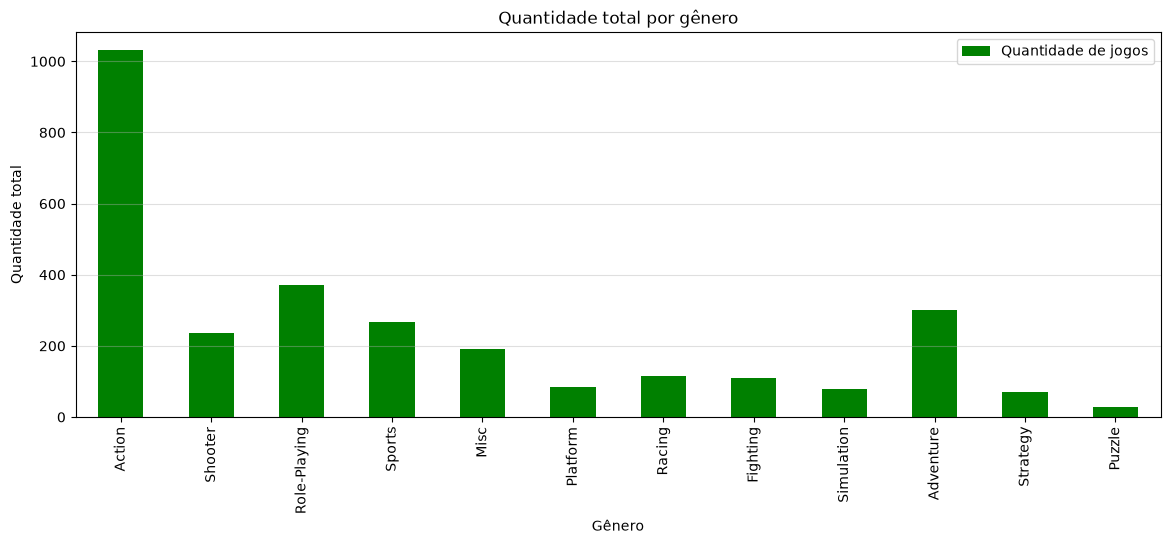

In [25]:
genre_analysis['game_count'].plot(kind='bar',
                    title='Quantidade total por gênero',
                    xlabel='Gênero',
                    ylabel='Quantidade total',
                    figsize=(14,5),
                    color='green')
plt.legend(labels=['Quantidade de jogos'])
plt.grid(axis='y', alpha=0.4)
plt.show()

O gráfico mostra, em quantidade, quantos jogos cada gênero possui (2012 em diante)

O gênero Ação demonstra forte domínio no mercado, tanto em vendas quanto em quantidade. O gênero Tiro (Shooter) acompanha as vendas de Ação, mas possui menos lançamentos em número.

A categoria 'Ação' é ampla e frequentemente engloba subgêneros (como tiro, aventura e plataforma), o que explica parte da diferença de contagem entre gêneros mais específicos.

Interessante notar que, embora haja mais títulos de RPG do que de Tiro, alguns jogos de Tiro tiveram sucesso comercial superior, elevando as vendas médias do gênero.


# Perfis de cada região

In [26]:
# PERFIL POR PLATAFORMA

eu_best_plat = df_recent_games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
na_best_plat = df_recent_games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
jp_best_plat = df_recent_games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
global_best_plat = pd.merge(eu_best_plat, na_best_plat, on='platform', how='outer')
global_best_plat = pd.merge(global_best_plat, jp_best_plat, on='platform', how='outer')

# PERFIL POR GÊNERO

eu_best_genre = df_recent_games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
na_best_genre = df_recent_games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
jp_best_genre = df_recent_games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
global_best_genre = pd.merge(eu_best_genre, na_best_genre, on='genre', how='outer')
global_best_genre = pd.merge(global_best_genre, jp_best_genre, on='genre', how='outer')

# PERFIL POR AVALIAÇÃO

eu_best_rate = df_recent_games.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).head(5)
na_best_rate = df_recent_games.groupby('rating')['na_sales'].sum().sort_values(ascending=False).head(5)
jp_best_rate = df_recent_games.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).head(5)
global_best_rate = pd.merge(eu_best_rate, na_best_rate, on='rating', how='outer')
global_best_rate = pd.merge(global_best_rate, jp_best_rate, on='rating', how='outer')

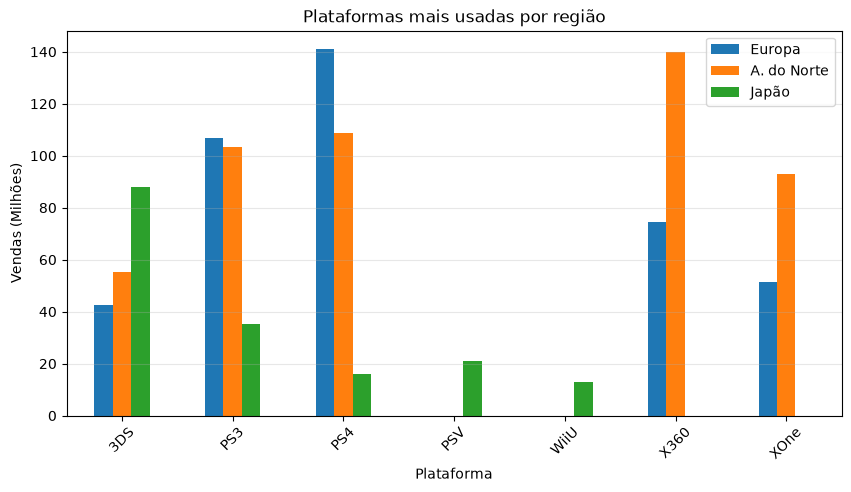

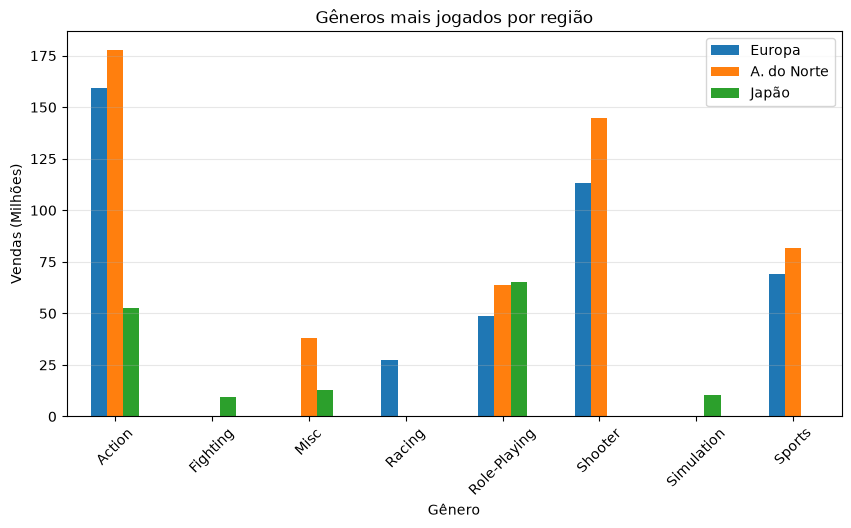

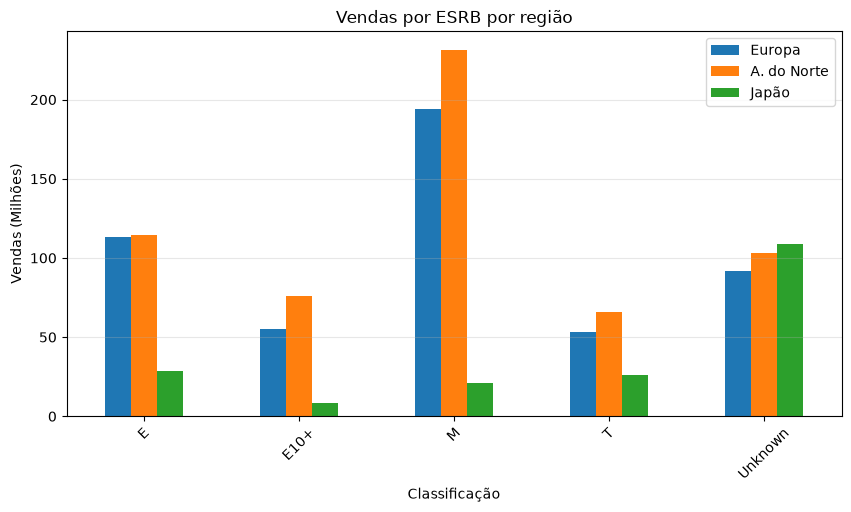

In [27]:
global_best_plat.plot(kind='bar',
                      title='Plataformas mais usadas por região',
                      xlabel='Plataforma',
                      ylabel='Vendas (Milhões)',
                      figsize=(10, 5),
                      rot=45)
plt.legend(labels=['Europa', 'A. do Norte', 'Japão'])
plt.grid(axis='y', alpha=0.3)
plt.show()
global_best_genre.plot(kind='bar',
                      title='Gêneros mais jogados por região',
                      xlabel='Gênero',
                      ylabel='Vendas (Milhões)',
                      figsize=(10, 5),
                      rot=45)
plt.legend(labels=['Europa', 'A. do Norte', 'Japão'])
plt.grid(axis='y', alpha=0.3)
plt.show()
global_best_rate.plot(kind='bar',
                      title='Vendas por ESRB por região',
                      xlabel='Classificação',
                      ylabel='Vendas (Milhões)',
                      figsize=(10, 5),
                      rot=45)
plt.legend(labels=['Europa', 'A. do Norte', 'Japão'])
plt.grid(axis='y', alpha=0.3)
plt.show()

# Conclusões sobre os perfis de cada região

### Plataformas
A Sony vem com dominancia na Europa, com PS3 e PS4 se destacando, em contrapartida com a Microsoft que administra as vendas do Xbox em todo território norte-americano\
Pelo lado oriental, o Japão mantém a preferência com o portáteis como 3DS e Wii, logo, as demais concorrentes não ficam entre as principais
### Gêneros
Japão segue dominando quando se trata de luta e simulação no mundo dos games, diferente da Europa e América do Norte, que tem preferência por jogos de ação, tiro e esporte
### Avaliações
No japão, a grande maioria das vendas concentra-se na categoria Unknown (sem classificação ESRB). Isso ocorre porque o Japão possui seu próprio órgão regulador.\
Por esse motivo, a classificação ESRB americana não impacta de forma direta a decisão de compra no mercado japonês.\
Já na América do Norte e Europa, os jogos de classificação adulta, geram mais receita

## Teste de hipóteses

### Primeira hipótese:
- H0 (Hipótese Nula): As classificações médias dos usuários das plataformas Xbox One e PC são iguais.
- H1 (Hipótese Alternativa): As classificações médias dos usuários das plataformas Xbox One e PC são diferentes.

In [28]:
xone_scores = df_recent_games[df_recent_games['platform'] == 'XOne']['user_score'].dropna() # Obtem as notas de usuarios da plataforma Xbox One, sem nulos
pc_scores = df_recent_games[df_recent_games['platform'] == 'PC']['user_score'].dropna() # Obtem as notas de usuarios da plataforma PC, sem nulos
print(f"Média XOne: {xone_scores.mean().round(2)}, Variância: {xone_scores.var().round(2)}, Desvio Padrão: {xone_scores.std().round(2)}") # Exibe os valores
print(f"Média PC: {pc_scores.mean().round(2)}, Variância: {pc_scores.var().round(2)}, Desvio Padrão: {pc_scores.std().round(2)}") # Exibe os valores

Média XOne: 6.52, Variância: 1.91, Desvio Padrão: 1.38
Média PC: 6.43, Variância: 2.77, Desvio Padrão: 1.66


As média das notas de ambas plataformas é bom proxima, o teste t será realizar para confirmar se a diferença é significativa ou apenas uma flutuação amostral

In [ ]:
alpha = 0.05 # Define o nivel de significancia
result_plat = st.ttest_ind(xone_scores, pc_scores, equal_var=False) # Realiza o teste
print(f"p-value:", result_plat.pvalue.round(2)) # Exibe o p-value

if result_plat.pvalue < alpha:
    print("Rejeitamos a hipótese nula: há diferença estatisticamente significativa entre as médias do XOne e PC.")
else:
    print("Não podemos rejeitar a hipótese nula: não há evidência de diferença estatisticamente significativa entre as médias do XOne e PC.")

p-value: 0.55
Não podemos rejeitar a hipótese nula: não há evidência de diferença estatisticamente significativa entre as médias do XOne e PC.


O valor-p obtido foi de 0,55, que é superior ao nível de significância de alpha = 0,05.\
Portanto, não rejeitamos a hipótese nula (H0). Não há evidências estatísticas suficientes para afirmar que existe diferença entre as avaliações médias dos usuários do Xbox One e do PC.

### Segunda hipótese:
- H0 (Hipótese Nula): As classificações médias dos usuários para os gêneros Action e Sports são iguais.
- H1 (Hipótese Alternativa): As classificações médias dos usuários para os gêneros Action e Sports são diferentes.

In [31]:
action_scores = df_recent_games[df_recent_games['genre'] == 'Action']['user_score'].dropna() # Obtem as notas de usuarios do genero Action (Ação) (Ação) (Ação) (Ação), sem nulos
sports_scores = df_recent_games[df_recent_games['genre'] == 'Sports']['user_score'].dropna() # Obtem as notas de usuarios da genero Sports, sem nulos
print(f"Média action: {action_scores.mean().round(2)}, Variância: {action_scores.var().round(2)}, Desvio Padrão: {action_scores.std().round(2)}") # Exibe os valores
print(f"Média sports: {sports_scores.mean().round(2)}, Variância: {sports_scores.var().round(2)}, Desvio Padrão: {sports_scores.std().round(2)}") # Exibe os valores

Média action: 6.83, Variância: 1.89, Desvio Padrão: 1.37
Média sports: 5.46, Variância: 3.02, Desvio Padrão: 1.74


A médias estão distantes umas das outras, o teste t será realizado novamente para confirmar a hipótese

In [ ]:
alpha = 0.05 # Define o nivel de significancia
result_genre = st.ttest_ind(action_scores, sports_scores, equal_var=False) # Realiza o teste
print(f"p-value:", result_genre.pvalue) # Exibe o p-value

if result_genre.pvalue < alpha:
    print("Rejeitamos a hipótese nula: há diferença estatistiamente significativa entre as médias de Action e Sports")
else:
    print("Não podemos rejeitar a hipótese nula: não há evidência de diferença estatistiamente significativa entre as médias dos gêneros")

p-value: 4.243077765726399e-20
Rejeitamos a hipótese nula: há diferença estatistiamente significativa entre as médias de Action e Sports


O valor-p obtido foi extremamente baixo (4,24 x 10^-20), muito inferior a alpha = 0,05.\
Portanto, rejeitamos a hipótese nula (H0). Há evidência estatística de que as classificações médias dos usuários para os gêneros Action e Sports são significativamente diferentes.

## Conclusão Geral do Projeto
1. Tratamento e Preparação dos DadosTratamento de Dados: 
- Padronizamos os nomes das colunas para minúsculas, convertemos tipos de dados (como a coluna year_of_release para inteiro) e tratamos a string 'tbd' (to be determined) na coluna user_score como NaN, convertendo-a para o tipo numérico float.
- Valores Ausentes: Identificamos dados ausentes em critic_score, user_score e rating. Para a classificação da ESRB, preenchemos os valores nulos com 'Unknown' para evitar a perda de volume de dados na análise regional.
2. Análise Exploratória e Perfil de Plataformas
- Ciclo de Vida: Plataformas de jogos levam em média de 3 a 5 anos para atingir o pico de vendas e cerca de 10 anos para desaparecerem completamente do mercado.
- Período Relevante (Dados Recentes): Definimos um recorte temporal focado no período recente para prever tendências do ano seguinte, identificando PS4, Xbox One e Nintendo 3DS como os principais consoles de receita.
- Impacto das Avaliações: Houve correlação positiva moderada entre a pontuação dos críticos e as vendas globais de jogos. As avaliações dos usuários demonstraram pouca ou nenhuma correlação direta com o volume de vendas.
3. Perfis Regionais de Consumo
- América do Norte e Europa: Apresentam comportamento de consumo muito similar. Preferem consoles de mesa (linha Xbox e PlayStation), consomem massivamente os gêneros Action e Shooter, e têm a maior fatia de vendas em jogos com classificação ESRB M (Mature).
- Japão: Ao oposto ao ocidente e liderado por consoles portáteis (Nintendo 3DS), o Japão tem preferência quase exclusiva por gêneros Role-Playing (RPG) e Action. A classificação ESRB não afeta o mercado japonês, prevalecendo títulos categorizados como 'Unknown' por ser regulado pelo órgão local.
4. Testes de Hipóteses Estatísticas
- Hipótese 1 (Xbox One vs PC): Não foi possível rejeitar a hipótese nula. Não há evidência estatisticamente significativa de diferença entre as classificações médias dos usuários para as plataformas Xbox One e PC
- Hipótese 2 (Action vs Sports): Rejeitou-se a hipótese nula. As classificações médias dos usuários para os gêneros Action e Sports são estatisticamente diferentes
5. Recomendação Estratégica para Campanhas
- Para alocação de orçamento no Ocidente (AN e Europa), investir fortemente em títulos de Ação e Shooter para PS4 e Xbox One, priorizando jogos de grande porte (classificação M).
- Para a região do Japão, focar exclusivamente em jogos do gênero RPG e Ação direcionados para o ecossistema portátil (Nintendo 3DS).